# Deep Learning Text Generation Assignment
## Text Generation using Vanilla RNN, LSTM, and GRU

This notebook designs and compares three neural sequence models that learn word order, grammar-like structure, and contextual dependencies from a custom text corpus:
- Vanilla SimpleRNN
- LSTM
- GRU

The models are trained on identical next-word prediction data and optimizer settings, then compared through their training-loss trajectories and generated text samples.


# Problem Statement
Design and implement a deep learning model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. Vanilla RNN
2. LSTM
3. GRU

The notebook completes the required learning tasks by using a custom paragraph corpus, larger embeddings, 128-unit hidden layers, 200 training epochs, and 10-word generation outputs.


In [1]:
import re
import random

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


# Load and Clean Custom Text Corpus
The assignment requires replacing boilerplate text with a custom paragraph corpus. The corpus below describes a realistic technology-learning setting and gives the sequence models repeated contextual patterns to learn.


In [2]:
raw_corpus = '''
In a quiet analytics lab, students explored how data can tell meaningful stories about people, products, and decisions.
They cleaned messy records, studied repeated patterns, and learned that careful preprocessing often determines model quality.
Deep learning helped them discover structure in language, because each word depended on earlier words and surrounding context.
Recurrent neural networks processed sentences step by step, carrying a hidden state from one word to the next word.
Long short term memory networks remembered important clues for longer passages and reduced the effect of vanishing gradients.
Gated recurrent units used fewer gates, trained efficiently, and still captured useful dependencies across the text sequence.
Every experiment taught the students that models improve when data is prepared well, parameters are chosen carefully, and results are compared honestly.
By the end of the project, the class could generate short technical sentences that reflected the vocabulary and rhythm of the training corpus.
'''

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s.]", " " , text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s*\.\s*", ".\n", text)
    return text.strip()

corpus = clean_text(raw_corpus)
print(corpus)


in a quiet analytics lab students explored how data can tell meaningful stories about people products and decisions.
they cleaned messy records studied repeated patterns and learned that careful preprocessing often determines model quality.
deep learning helped them discover structure in language because each word depended on earlier words and surrounding context.
recurrent neural networks processed sentences step by step carrying a hidden state from one word to the next word.
long short term memory networks remembered important clues for longer passages and reduced the effect of vanishing gradients.
gated recurrent units used fewer gates trained efficiently and still captured useful dependencies across the text sequence.
every experiment taught the students that models improve when data is prepared well parameters are chosen carefully and results are compared honestly.
by the end of the project the class could generate short technical sentences that reflected the vocabulary and rhythm

# Tokenization and Progressive N-Gram Sequence Creation
The cleaned corpus is converted into integer word indexes. Each line is reframed into progressive sliding-window n-gram combinations for supervised next-word prediction, then padded to a common length.


In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}

print("Maximum sequence length:", max_len)
print("X shape:", X.shape)
print("y shape:", y.shape)


Vocabulary size: 121
Maximum sequence length: 23
X shape: (143, 22)
y shape: (143,)


# Shared Model Configuration
All three models use the same embedding size, hidden-unit count, epoch count, loss function, metric, and Adam optimizer configuration so the comparison is fair.


In [4]:
EMBEDDING_DIM = 64
HIDDEN_UNITS = 128
EPOCHS = 200
OPTIMIZER_CONFIG = {"learning_rate": 0.001}


def compile_model(model):
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(**OPTIMIZER_CONFIG),
        metrics=['accuracy']
    )
    return model


# Model 1: Vanilla SimpleRNN
This baseline sequential model learns short-range patterns through a recurrent hidden state.


In [5]:
rnn_model = Sequential([
    Input(shape=(max_len - 1,)),
    Embedding(total_words, EMBEDDING_DIM),
    SimpleRNN(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

compile_model(rnn_model)
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("Vanilla RNN training completed")


Vanilla RNN training completed


# Model 2: LSTM
LSTM uses input, forget, and output gates to preserve useful long-term context.


In [6]:
lstm_model = Sequential([
    Input(shape=(max_len - 1,)),
    Embedding(total_words, EMBEDDING_DIM),
    LSTM(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

compile_model(lstm_model)
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("LSTM training completed")


LSTM training completed


# Model 3: GRU
GRU uses reset and update gates, making it a compact gated alternative to LSTM.


In [7]:
gru_model = Sequential([
    Input(shape=(max_len - 1,)),
    Embedding(total_words, EMBEDDING_DIM),
    GRU(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

compile_model(gru_model)
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("GRU training completed")


GRU training completed


# Compare Optimization Trajectories
The line plot maps the training-loss trajectory of each architecture and shows how quickly each model stabilizes.


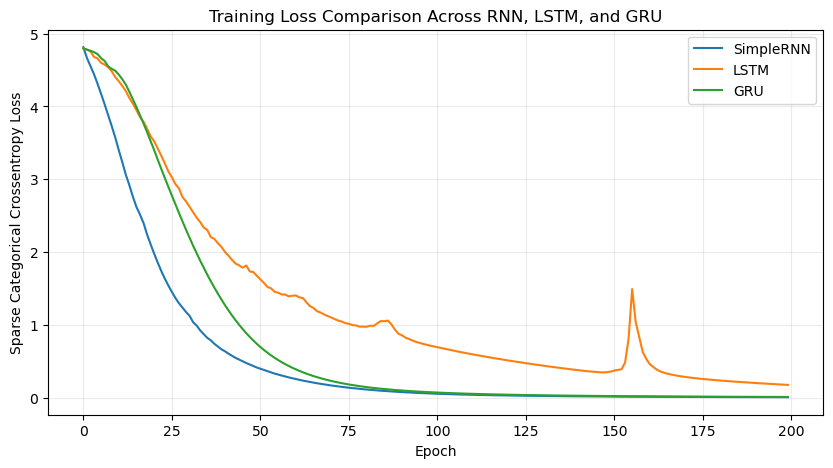

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history['loss'], label='SimpleRNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Sparse Categorical Crossentropy Loss")
plt.title("Training Loss Comparison Across RNN, LSTM, and GRU")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# Text Generation Function
The function repeatedly predicts the next word and uses np.argmax over the next-word probability array for deterministic internal selection.


In [9]:
def generate_text(model, seed_text, next_words=10):
    generated_text = clean_text(seed_text).replace('\n', ' ')

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([generated_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')
        next_word_probabilities = model.predict(token_list, verbose=0)
        predicted_index = int(np.argmax(next_word_probabilities[0]))

        output_word = reverse_word_index.get(predicted_index, '')
        if not output_word:
            break
        generated_text += ' ' + output_word

    return generated_text


# Generate 10-Word Text Samples


In [10]:
prompt = "deep learning"
print("RNN :", generate_text(rnn_model, prompt, next_words=10))
print("LSTM:", generate_text(lstm_model, prompt, next_words=10))
print("GRU :", generate_text(gru_model, prompt, next_words=10))


RNN : deep learning helped them discover structure in language because each word depended


LSTM: deep learning helped them discover structure in language because each word depended


GRU : deep learning helped them discover structure in language because each word depended


# Assignment Completion Checklist
- Custom paragraph corpus used and cleaned before tokenization.
- Standard Keras Tokenizer maps words to integer indexes.
- Progressive n-gram sequences are built and padded with pad_sequences.
- Three separate models are implemented: SimpleRNN, LSTM, and GRU.
- All models use 64-dimensional embeddings, 128 hidden units, Adam with learning rate 0.001, and 200 epochs.
- Training-loss trajectories are plotted for stabilization comparison.
- generate_text uses np.argmax over next-word probability arrays.
- Each generation prompt returns 10 predicted words.


# Conclusion
The Vanilla SimpleRNN provides a useful baseline for sequence modeling, while LSTM and GRU add gating mechanisms that help preserve context across longer word sequences. Comparing loss curves and generated samples makes it possible to observe differences in training stability and language quality across the three architectures.
